# Libraries

In [79]:
import pandas as pd
import ast
import seaborn as sns
import matplotlib.pyplot as plt

# Reading Data

In [80]:
data = pd.read_csv('Data/emg_streamed_cleaned.csv')
data.head()

,session_id,level_number,filtered_values,envelope_values
0,196,1,"[511.0, 511.0, 511.0, 511.0, 511.0, 511.0, 511...","[419.0, 278.3333333333333, 278.3333333333333, ..."
1,196,2,"[389.3333333333333, 651.0, 483.6666666666667, ...","[606.6666666666666, 713.3333333333334, 710.0, ..."
2,196,3,"[511.0, 511.0, 511.0, 511.0, 511.0, 511.0, 511...","[161.66666666666666, 149.66666666666666, 149.6..."
3,196,4,"[511.0, 489.6666666666667, 511.0, 511.0, 511.0...","[190.33333333333334, 186.0, 186.0, 186.3333333..."
4,270,1,"[542.3333333333334, 542.3333333333334, 542.333...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


# Cleaning

Dropping id column

In [81]:
data = data.drop("session_id", axis=1)
data.head()

,level_number,filtered_values,envelope_values
0,1,"[511.0, 511.0, 511.0, 511.0, 511.0, 511.0, 511...","[419.0, 278.3333333333333, 278.3333333333333, ..."
1,2,"[389.3333333333333, 651.0, 483.6666666666667, ...","[606.6666666666666, 713.3333333333334, 710.0, ..."
2,3,"[511.0, 511.0, 511.0, 511.0, 511.0, 511.0, 511...","[161.66666666666666, 149.66666666666666, 149.6..."
3,4,"[511.0, 489.6666666666667, 511.0, 511.0, 511.0...","[190.33333333333334, 186.0, 186.0, 186.3333333..."
4,1,"[542.3333333333334, 542.3333333333334, 542.333...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


Filtered and enevlope values are read as strings instead of list

In [82]:
# convert lists from string to list
data['filtered_values'] = data['filtered_values'].apply(ast.literal_eval)
data['envelope_values'] = data['envelope_values'].apply(ast.literal_eval)

Mapping level numbers to their categories

* 1 -> Relaxed
* 2 -> Max
* 3 -> Light
* 4 -> Preferance

In [83]:
level_mapping = {
    1: 'Relaxed',
    2: 'Max Contraction',
    3: 'Light Contraction',
    4: 'Prefrence Contraction'
}

data['level_number'] = data['level_number'].map(level_mapping)

Data grouping per level

In [84]:
# Create a dictionary of dataframes
level_groups = {level: df for level, df in data.groupby('level_number')}

# How to access them:
# df_level_1 = level_groups[1]
# df_level_2 = level_groups[2]

for level, df in level_groups.items():
    print(f"Level {level}: {len(df)} rows")

Level Light Contraction: 8 rows
Level Max Contraction: 9 rows
Level Prefrence Contraction: 8 rows
Level Relaxed: 9 rows


In [85]:
data.head()

,level_number,filtered_values,envelope_values
0,Relaxed,"[511.0, 511.0, 511.0, 511.0, 511.0, 511.0, 511...","[419.0, 278.3333333333333, 278.3333333333333, ..."
1,Max Contraction,"[389.3333333333333, 651.0, 483.6666666666667, ...","[606.6666666666666, 713.3333333333334, 710.0, ..."
2,Light Contraction,"[511.0, 511.0, 511.0, 511.0, 511.0, 511.0, 511...","[161.66666666666666, 149.66666666666666, 149.6..."
3,Prefrence Contraction,"[511.0, 489.6666666666667, 511.0, 511.0, 511.0...","[190.33333333333334, 186.0, 186.0, 186.3333333..."
4,Relaxed,"[542.3333333333334, 542.3333333333334, 542.333...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


# EDA

In [86]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   level_number     34 non-null     str   
 1   filtered_values  34 non-null     object
 2   envelope_values  34 non-null     object
dtypes: object(2), str(1)
memory usage: 948.0+ bytes


### Nulls check

In [87]:
data.isna().sum()

level_number       0
filtered_values    0
envelope_values    0
dtype: int64

No nulls

### Duplication Check

In [88]:
# turning lists into tuples as lists are unhashable so they don't work with .duplicated()
temp_data = data.copy()
temp_data['filtered_values'] = temp_data['filtered_values'].apply(tuple)
temp_data['envelope_values'] = temp_data['envelope_values'].apply(tuple)

In [89]:
data[temp_data.duplicated(keep=False)]

,level_number,filtered_values,envelope_values


No duplicates

### Statistics

In [90]:
data.describe()

,level_number,filtered_values,envelope_values
count,34,34,34
unique,4,32,34
top,Relaxed,"[511.0, 511.0, 511.0, 511.0, 511.0, 511.0, 511...","[419.0, 278.3333333333333, 278.3333333333333, ..."
freq,9,2,1


#### All Levels

Only level_number is single value, filtered and envelope have lists
-> explode the list to be several rows to be able to describe it

In [91]:
data['filtered_values'].explode().astype(float).describe()

count    9098.000000
mean      518.220195
std        32.763100
min       240.000000
25%       511.000000
50%       511.000000
75%       529.000000
max       744.000000
Name: filtered_values, dtype: float64

In [92]:
data['envelope_values'].explode().astype(float).describe()

count    9098.000000
mean      174.007566
std       218.892420
min         0.000000
25%        11.000000
50%        71.500000
75%       268.916667
max       888.000000
Name: envelope_values, dtype: float64

Envelope values are more widespread
seen by the std and quartiles

#### Level by level

In [93]:
for level in level_groups:
    print(f"Level: {level}")
    print(level_groups[level]['filtered_values'].explode().astype(float).describe())
    print("\n") 

Level: Light Contraction
count    2235.000000
mean      517.657122
std        17.167362
min       464.666667
25%       511.000000
50%       511.000000
75%       520.000000
max       558.000000
Name: filtered_values, dtype: float64


Level: Max Contraction
count    2316.000000
mean      513.808866
std        56.102951
min       240.000000
25%       489.666667
50%       511.000000
75%       542.333333
max       744.000000
Name: filtered_values, dtype: float64


Level: Prefrence Contraction
count    2224.000000
mean      518.412770
std        23.138625
min       383.000000
25%       511.000000
50%       511.000000
75%       529.000000
max       610.666667
Name: filtered_values, dtype: float64


Level: Relaxed
count    2323.000000
mean      522.975606
std        15.127546
min       511.000000
25%       511.000000
50%       511.000000
75%       542.333333
max       624.666667
Name: filtered_values, dtype: float64




In [94]:
for level in level_groups:
    print(f"Level: {level}")
    print(level_groups[level]['envelope_values'].explode().astype(float).describe())
    print("\n") 

Level: Light Contraction
count    2235.000000
mean       42.344519
std        45.411641
min         0.000000
25%        11.000000
50%        31.000000
75%        50.333333
max       170.000000
Name: envelope_values, dtype: float64


Level: Max Contraction
count    2316.000000
mean      475.127879
std       208.518810
min        17.666667
25%       313.458333
50%       495.000000
75%       641.666667
max       888.000000
Name: envelope_values, dtype: float64


Level: Prefrence Contraction
count    2224.000000
mean      130.935552
std        95.439396
min         0.000000
25%        63.250000
50%        95.000000
75%       186.333333
max       410.666667
Name: envelope_values, dtype: float64


Level: Relaxed
count    2323.000000
mean       41.706414
std        85.135767
min         0.000000
25%         0.000000
50%         0.000000
75%        11.333333
max       419.000000
Name: envelope_values, dtype: float64




#### Outliers - Boxplot

##### All values

Filtered Column

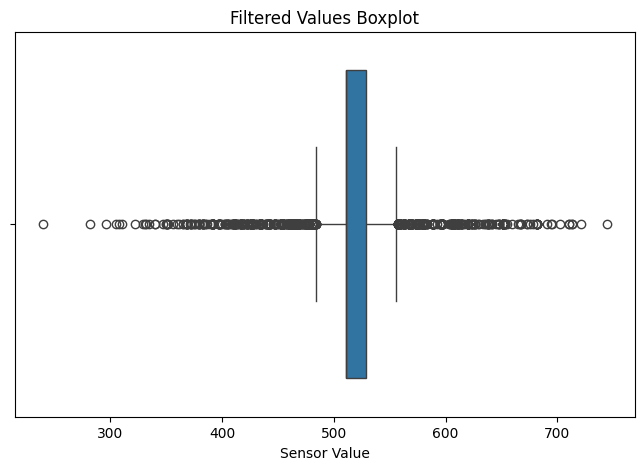

In [95]:
# flatten using explode()
plt.figure(figsize=(8, 5))
sns.boxplot(x=data['filtered_values'].explode().astype(float))

plt.title('Filtered Values Boxplot')
plt.xlabel('Sensor Value')
plt.show()

Envelope Column

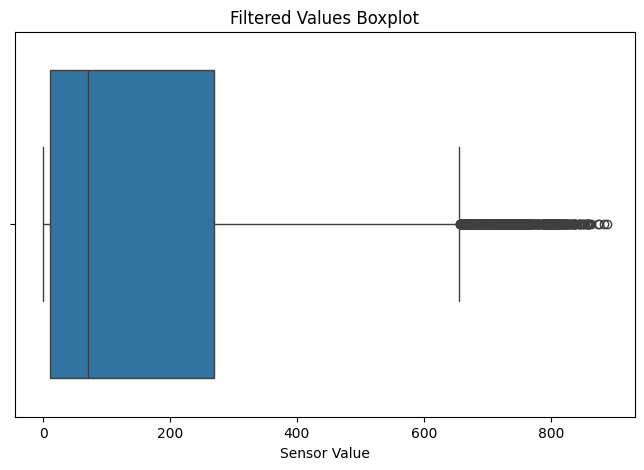

In [96]:
# flatten using explode()
plt.figure(figsize=(8, 5))
sns.boxplot(x=data['envelope_values'].explode().astype(float))

plt.title('Filtered Values Boxplot')
plt.xlabel('Sensor Value')
plt.show()

##### Level by level

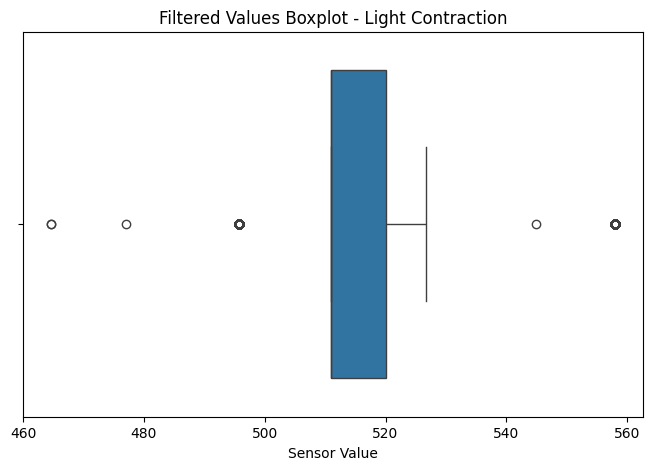

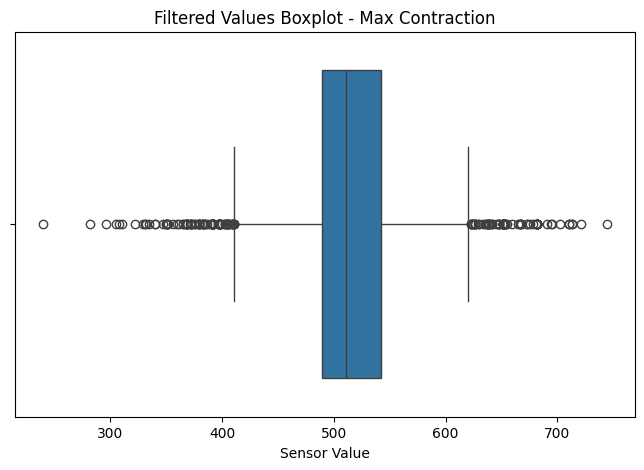

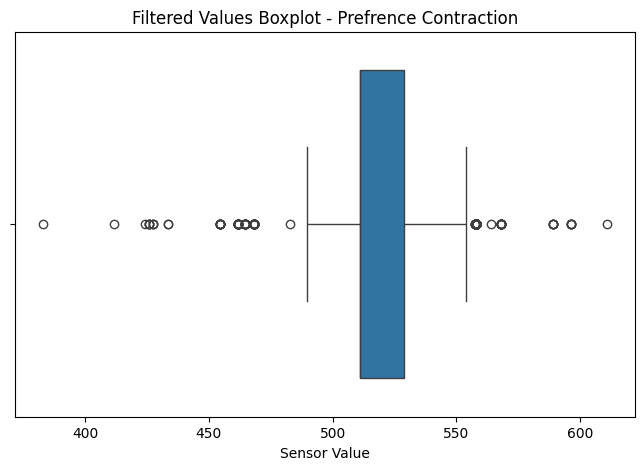

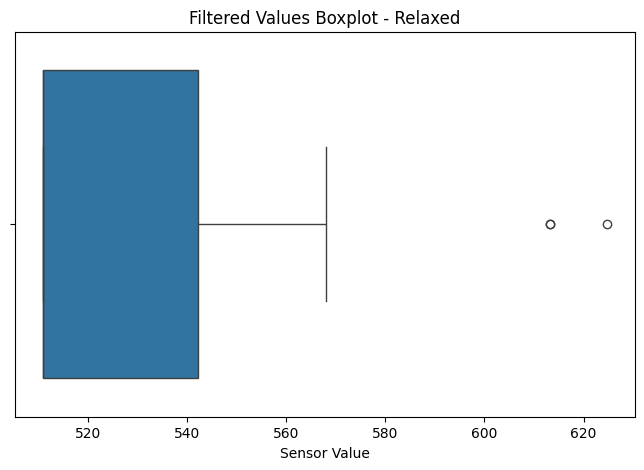

In [97]:
for level, df in level_groups.items():
    plt.figure(figsize=(8, 5))
    # Explode the list of values and convert to float for plotting
    sns.boxplot(x=df['filtered_values'].explode().astype(float))
    plt.title(f'Filtered Values Boxplot - {level}')
    plt.xlabel('Sensor Value')
    plt.show()

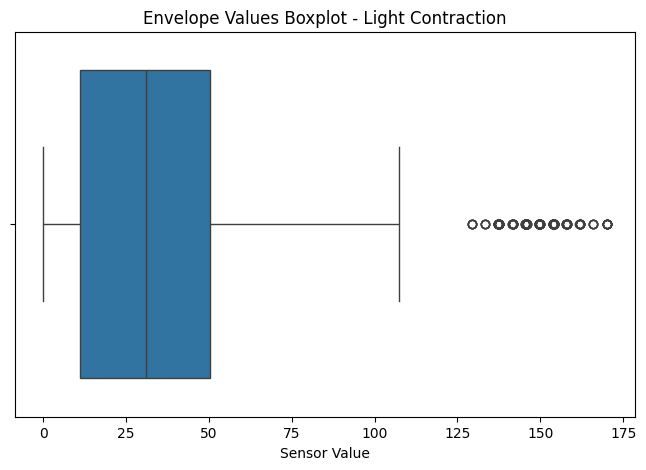

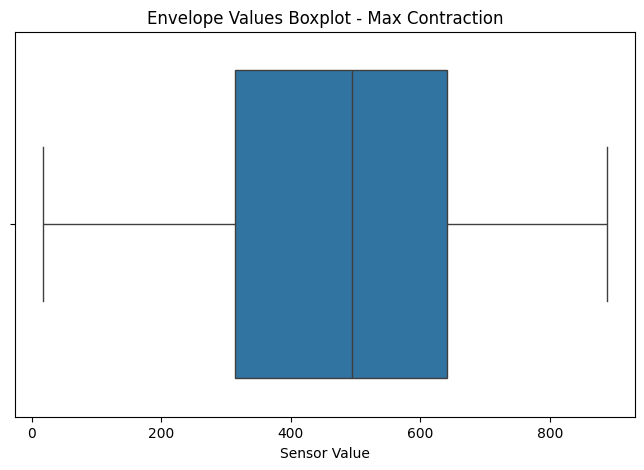

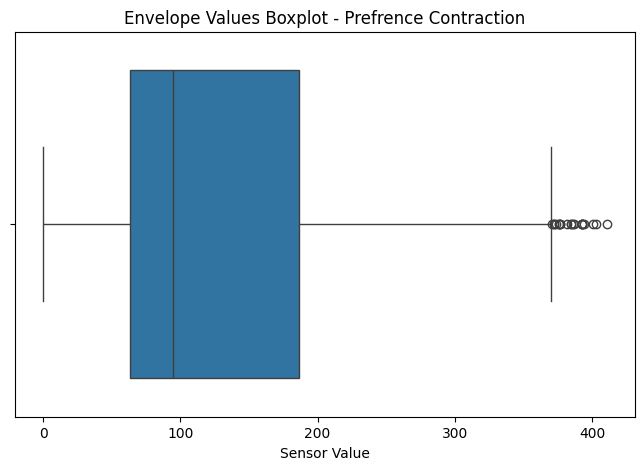

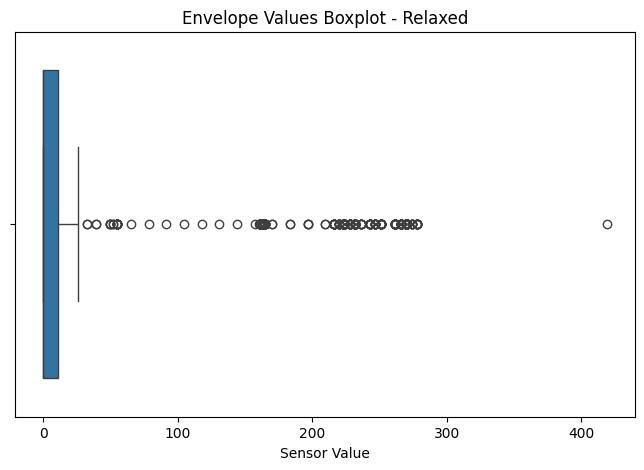

In [98]:
for level, df in level_groups.items():
    plt.figure(figsize=(8, 5))
    # Explode the list of values and convert to float for plotting
    sns.boxplot(x=df['envelope_values'].explode().astype(float))
    plt.title(f'Envelope Values Boxplot - {level}')
    plt.xlabel('Sensor Value')
    plt.show()

#### Outliers - Histogram

##### All values

Filtered Column

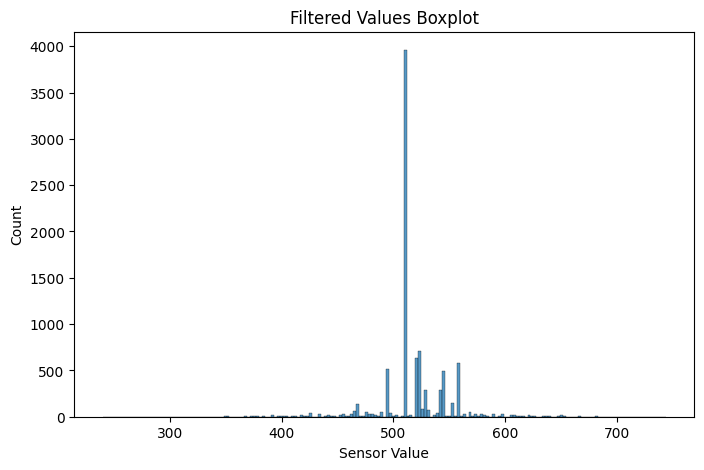

In [ ]:
# flatten using explode()
plt.figure(figsize=(8, 5))
sns.histplot(x=data['filtered_values'].explode().astype(float))
plt.title('Filtered Values Boxplot')
plt.xlabel('Sensor Value')
plt.show()

Envelope Column

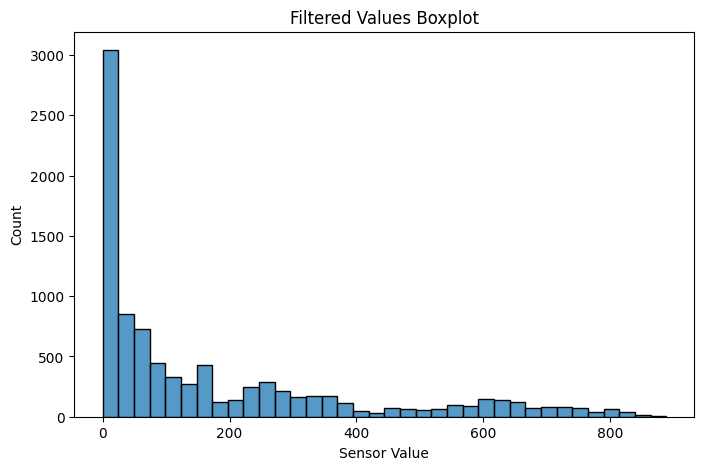

In [100]:
# flatten using explode()
plt.figure(figsize=(8, 5))
sns.histplot(x=data['envelope_values'].explode().astype(float))

plt.title('Filtered Values Boxplot')
plt.xlabel('Sensor Value')
plt.show()

##### Level by level

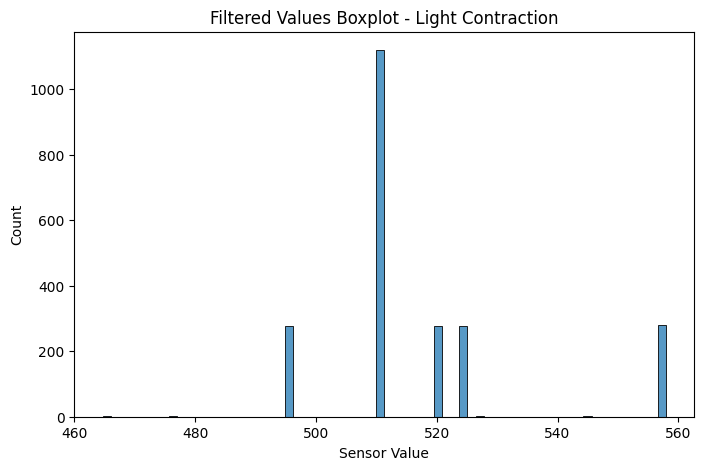

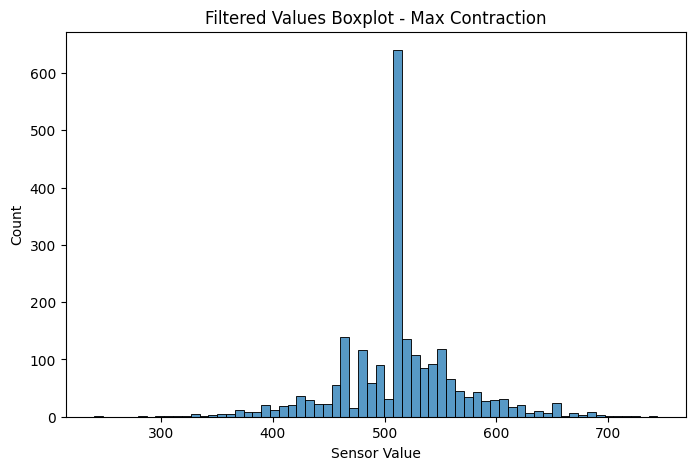

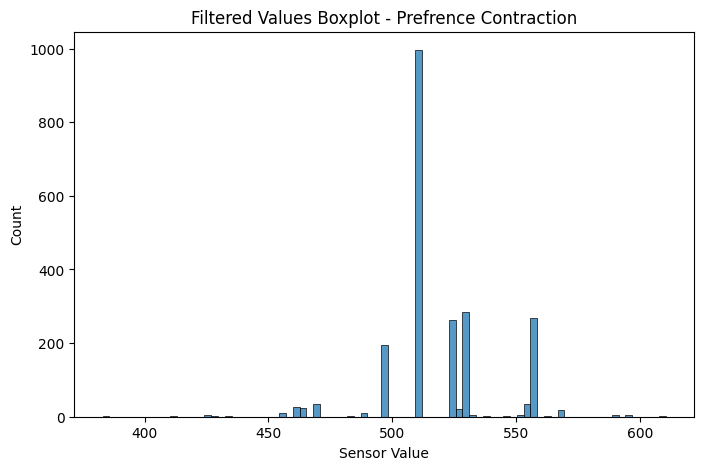

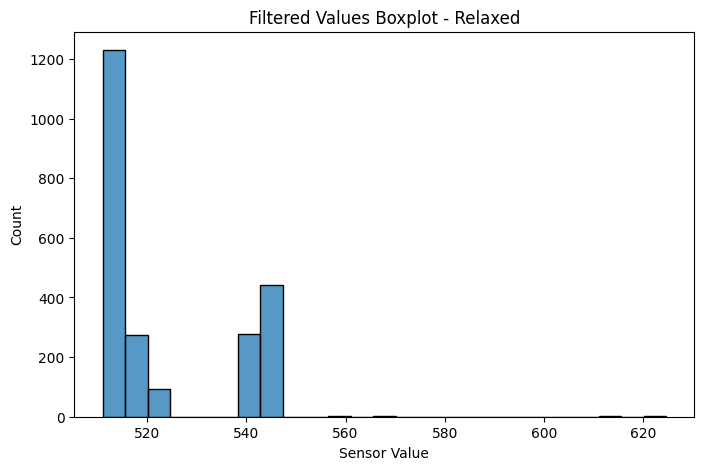

In [101]:
for level, df in level_groups.items():
    plt.figure(figsize=(8, 5))
    # Explode the list of values and convert to float for plotting
    sns.histplot(x=df['filtered_values'].explode().astype(float))
    plt.title(f'Filtered Values Boxplot - {level}')
    plt.xlabel('Sensor Value')
    plt.show()

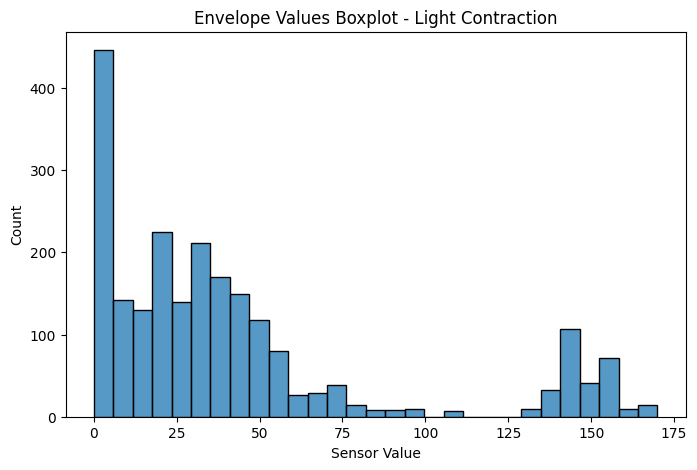

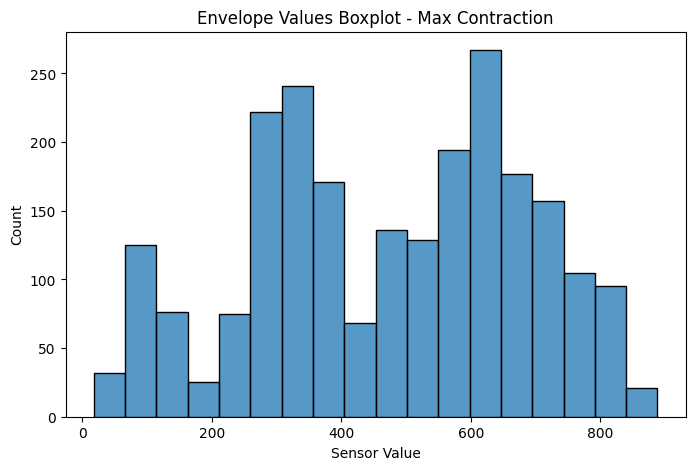

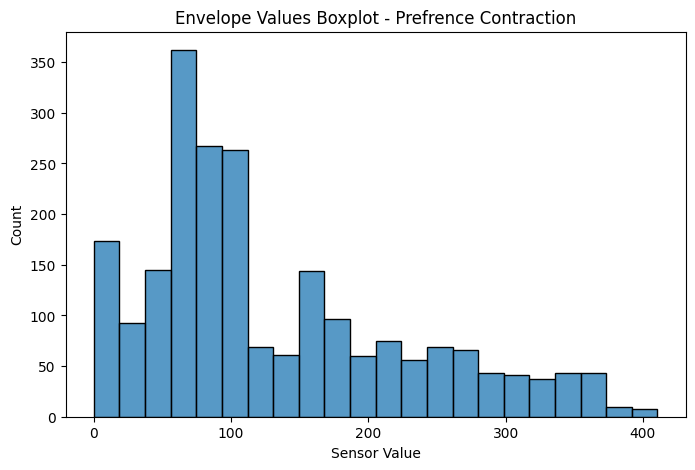

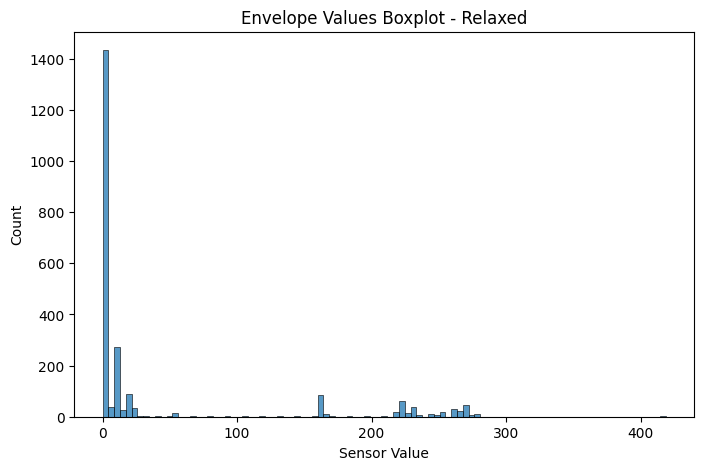

In [102]:
for level, df in level_groups.items():
    plt.figure(figsize=(8, 5))
    # Explode the list of values and convert to float for plotting
    sns.histplot(x=df['envelope_values'].explode().astype(float))
    plt.title(f'Envelope Values Boxplot - {level}')
    plt.xlabel('Sensor Value')
    plt.show()